# EDA — Dataset de caidas

Analisis exploratorio del dataset etiquetado con `label_tool.py` (bounding box
por persona) y armado con `convert_dataset.py`. Sigue cuatro bloques: auditoria
de archivos, contenido de pixel, balance de clases, y duplicados/proyeccion de
embeddings.

Fuentes de datos:

- `data/raw/labeled/` — imagenes crudas ya procesadas por el etiquetador (una vez que se confirmo "Listo" para cada una).
- `data/raw/pool/pool_log.csv` — procedencia de cada imagen (`pexels` / `video`).
- `data/raw/bbox_log.csv` — una fila por **persona** etiquetada (filename, label, box normalizado).
- `data/processed/dataset_labels.csv` — el dataset final ya recortado y dividido en train/valid/test.


In [21]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

ROOT = pathlib.Path.cwd().resolve().parents[0] if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.append(str(ROOT))

RAW_DIR = ROOT / "data" / "raw"
LABELED_DIR = RAW_DIR / "labeled"
PROCESSED_DIR = ROOT / "data" / "processed"

# Paleta categorica (orden fijo, validada para contraste y CVD: ver dataviz skill)
BLUE = "#2a78d6"
AQUA = "#1baf7a"
YELLOW = "#eda100"
RED = "#e34948"
INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})


In [22]:
pool_log = pd.read_csv(RAW_DIR / "pool" / "pool_log.csv")
bbox_log = pd.read_csv(RAW_DIR / "bbox_log.csv")
dataset_labels = pd.read_csv(PROCESSED_DIR / "dataset_labels.csv")

# Cada persona etiquetada hereda el source de su imagen original
bbox_log = bbox_log.merge(
    pool_log[["filename", "source"]], on="filename", how="left"
)

n_pool_total = len(pool_log)
n_images_labeled = bbox_log["filename"].nunique()
n_people = len(bbox_log)
n_dataset = len(dataset_labels)

print(f"Imagenes scrapeadas/extraidas (pool_log.csv):      {n_pool_total}")
print(f"Imagenes con al menos una persona etiquetada:      {n_images_labeled}")
print(f"Personas etiquetadas (filas de bbox_log.csv):      {n_people}")
print(f"Ejemplos en el dataset final (recortes):           {n_dataset}")
print(f"Promedio de personas por imagen etiquetada:        {n_people / n_images_labeled:.2f}")


Imagenes scrapeadas/extraidas (pool_log.csv):      567
Imagenes con al menos una persona etiquetada:      341
Personas etiquetadas (filas de bbox_log.csv):      496
Ejemplos en el dataset final (recortes):           496
Promedio de personas por imagen etiquetada:        1.45


## 1. Auditoria de metadatos y archivos

Antes de mirar contenido o clases, se valida la integridad de los archivos
crudos en `data/raw/labeled/`: formatos presentes, archivos corruptos o de
0 KB, resolucion y aspect ratio de cada imagen. Esto es lo que determina si
hace falta un reescalado drastico o si hay que descartar capturas rotas antes
de entrenar.


In [23]:
raw_files = sorted(LABELED_DIR.glob("*.*"))

file_records = []
for f in raw_files:
    rec = {"filename": f.name, "ext": f.suffix.lower(), "size_bytes": f.stat().st_size}
    try:
        with Image.open(f) as img:
            img.verify()
        with Image.open(f) as img:  # verify() invalida el objeto, hay que reabrir
            rec["width"], rec["height"] = img.size
            rec["mode"] = img.mode
        rec["corrupt"] = False
    except Exception as exc:
        rec["width"] = rec["height"] = None
        rec["mode"] = None
        rec["corrupt"] = True
        rec["error"] = str(exc)
    file_records.append(rec)

files_df = pd.DataFrame(file_records)
files_df["aspect_ratio"] = files_df["width"] / files_df["height"]

print(f"Archivos auditados: {len(files_df)}")
print(f"Formatos presentes:\n{files_df['ext'].value_counts().to_string()}")

zero_kb = files_df[files_df["size_bytes"] == 0]
corrupt = files_df[files_df["corrupt"]]
print(f"\nArchivos de 0 KB: {len(zero_kb)}")
print(f"Archivos corruptos (no abren con PIL): {len(corrupt)}")
if len(corrupt):
    print(corrupt[["filename", "error"]].to_string(index=False))


Archivos auditados: 341
Formatos presentes:
ext
.jpg    341

Archivos de 0 KB: 0
Archivos corruptos (no abren con PIL): 0


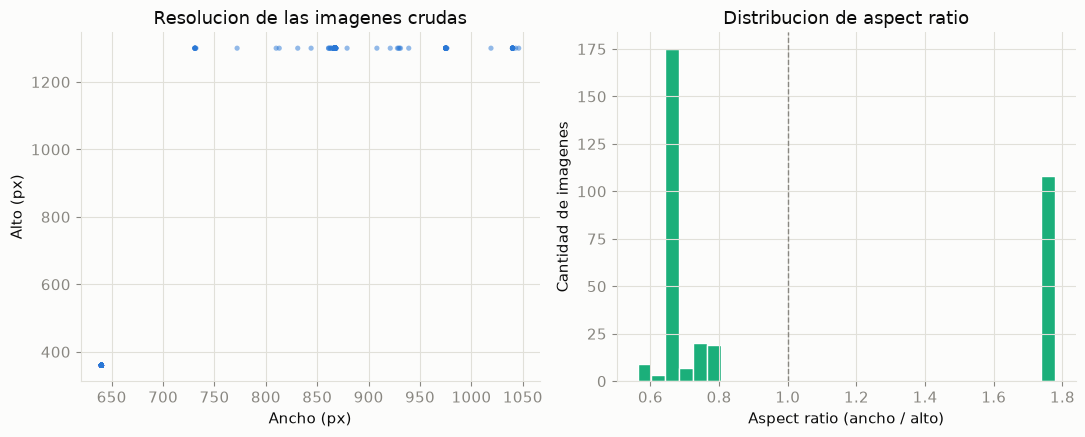

           width      height  aspect_ratio
mean   808.27566  1002.28739      1.028879
min    640.00000   360.00000      0.562308
max   1046.00000  1300.00000      1.777778


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

valid = files_df.dropna(subset=["width", "height"])
axes[0].scatter(valid["width"], valid["height"], s=14, color=BLUE, alpha=0.5, edgecolors="none")
axes[0].set_xlabel("Ancho (px)")
axes[0].set_ylabel("Alto (px)")
axes[0].set_title("Resolucion de las imagenes crudas")

axes[1].hist(valid["aspect_ratio"], bins=30, color=AQUA, edgecolor="white")
axes[1].axvline(1.0, color=MUTED, linestyle="--", linewidth=1)
axes[1].set_xlabel("Aspect ratio (ancho / alto)")
axes[1].set_ylabel("Cantidad de imagenes")
axes[1].set_title("Distribucion de aspect ratio")

plt.tight_layout()
plt.show()

print(valid[["width", "height", "aspect_ratio"]].describe().loc[["mean", "min", "max"]])


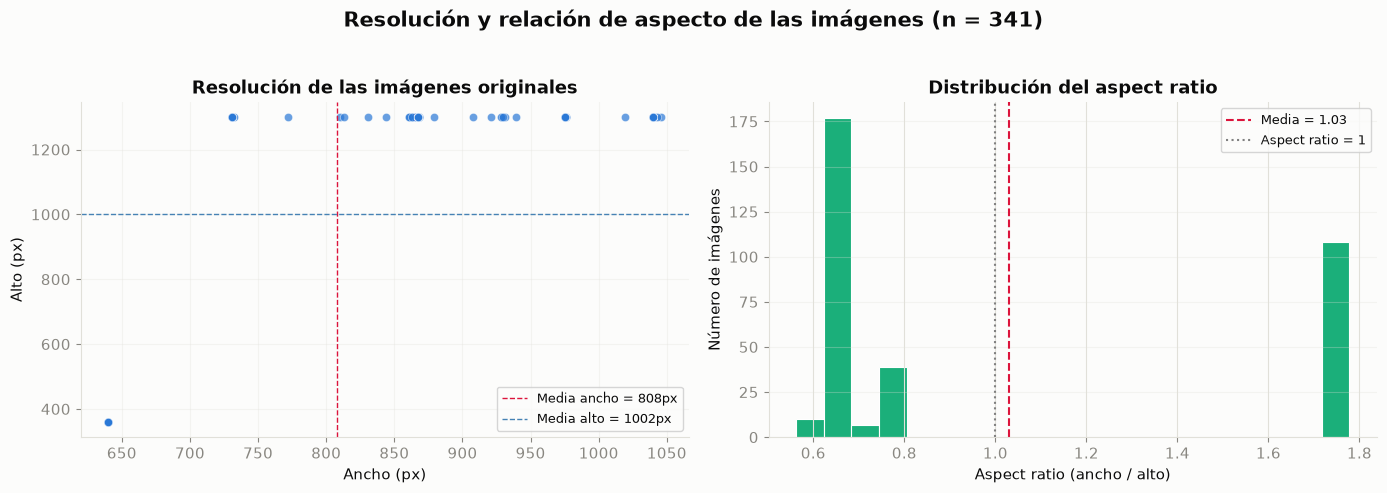

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid = files_df.dropna(subset=["width", "height"])

# =========================
# Scatter de resolución
# =========================
axes[0].scatter(
    valid["width"],
    valid["height"],
    s=35,
    color=BLUE,
    alpha=0.7,
    edgecolors="white",
    linewidth=0.4
)

axes[0].axvline(valid["width"].mean(),
                color="crimson",
                linestyle="--",
                linewidth=1,
                label=f"Media ancho = {valid['width'].mean():.0f}px")

axes[0].axhline(valid["height"].mean(),
                color="steelblue",
                linestyle="--",
                linewidth=1,
                label=f"Media alto = {valid['height'].mean():.0f}px")

axes[0].set_title("Resolución de las imágenes originales", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Ancho (px)")
axes[0].set_ylabel("Alto (px)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# =========================
# Histograma
# =========================
axes[1].hist(
    valid["aspect_ratio"],
    bins=20,
    color=AQUA,
    edgecolor="white",
    linewidth=0.8
)

axes[1].axvline(
    valid["aspect_ratio"].mean(),
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"Media = {valid['aspect_ratio'].mean():.2f}"
)

axes[1].axvline(
    1.0,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="Aspect ratio = 1"
)

axes[1].set_title("Distribución del aspect ratio", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Aspect ratio (ancho / alto)")
axes[1].set_ylabel("Número de imágenes")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(fontsize=9)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle(
    f"Resolución y relación de aspecto de las imágenes (n = {len(valid)})",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 2. Analisis del contenido visual (propiedades de pixel)

Estadisticas de la matriz de pixeles de cada imagen: brillo y contraste
(media/desvio de la intensidad en gris), nitidez (varianza del Laplaciano —
valores bajos sugieren imagenes borrosas) y el balance de los canales RGB.


In [26]:
pixel_records = []
for f in raw_files:
    img_bgr = cv2.imread(str(f))
    if img_bgr is None:
        continue
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    b, g, r = cv2.mean(img_bgr)[:3]
    pixel_records.append({
        "filename": f.name,
        "brightness": gray.mean(),
        "contrast": gray.std(),
        "sharpness": cv2.Laplacian(gray, cv2.CV_64F).var(),
        "mean_r": r, "mean_g": g, "mean_b": b,
        "mean_saturation": hsv[:, :, 1].mean(),
    })

pixel_df = pd.DataFrame(pixel_records)
print(pixel_df[["brightness", "contrast", "sharpness", "mean_saturation"]].describe().loc[["mean", "std", "min", "max"]])


      brightness    contrast    sharpness  mean_saturation
mean   83.905384   60.558901   416.567969        54.321382
std    45.966296   15.218029   568.762838        41.136223
min     8.458121    9.227076     8.597254         0.000000
max   222.877172  102.094936  5989.588351       215.506360


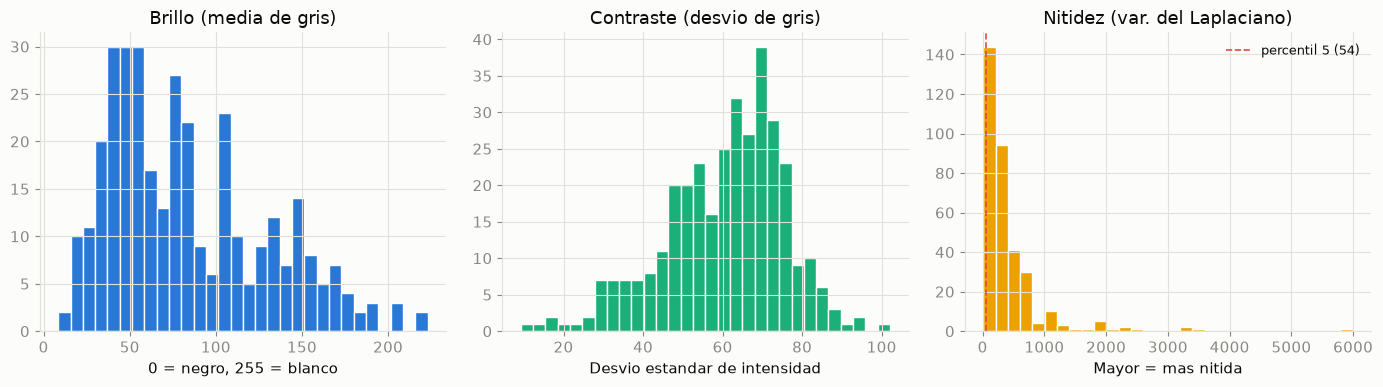

Las 5 imagenes menos nitidas (candidatas a revisar):
          filename  sharpness
img_939fb0bdbb.jpg   8.597254
img_e968b663fd.jpg  10.808893
img_48e60eef2f.jpg  16.042107
img_d114c52a37.jpg  17.671898
img_869c6c4e52.jpg  17.951824


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(pixel_df["brightness"], bins=30, color=BLUE, edgecolor="white")
axes[0].set_title("Brillo (media de gris)")
axes[0].set_xlabel("0 = negro, 255 = blanco")

axes[1].hist(pixel_df["contrast"], bins=30, color=AQUA, edgecolor="white")
axes[1].set_title("Contraste (desvio de gris)")
axes[1].set_xlabel("Desvio estandar de intensidad")

p5 = pixel_df["sharpness"].quantile(0.05)
axes[2].hist(pixel_df["sharpness"], bins=30, color=YELLOW, edgecolor="white")
axes[2].axvline(p5, color=RED, linestyle="--", linewidth=1.2, label=f"percentil 5 ({p5:.0f})")
axes[2].set_title("Nitidez (var. del Laplaciano)")
axes[2].set_xlabel("Mayor = mas nitida")
axes[2].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

blurriest = pixel_df.nsmallest(5, "sharpness")[["filename", "sharpness"]]
print("Las 5 imagenes menos nitidas (candidatas a revisar):")
print(blurriest.to_string(index=False))


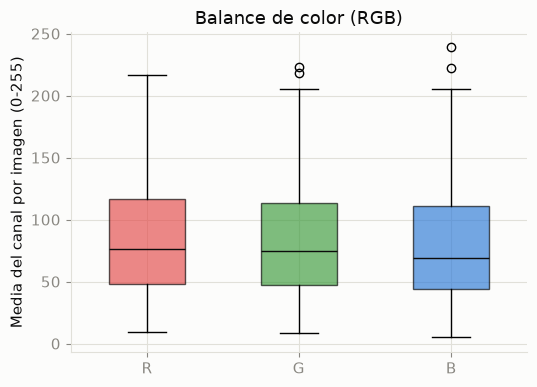

In [28]:
fig, ax = plt.subplots(figsize=(5.5, 4))
channel_means = pixel_df[["mean_r", "mean_g", "mean_b"]]
bp = ax.boxplot(
    [channel_means["mean_r"], channel_means["mean_g"], channel_means["mean_b"]],
    tick_labels=["R", "G", "B"], patch_artist=True, widths=0.5,
)
for patch, color in zip(bp["boxes"], [RED, "#3a9a3a", BLUE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
for median in bp["medians"]:
    median.set_color(INK)

ax.set_ylabel("Media del canal por imagen (0-255)")
ax.set_title("Balance de color (RGB)")
plt.tight_layout()
plt.show()


## 3. Distribucion y balance de clases

### 3.1 Balance fall / no_fall

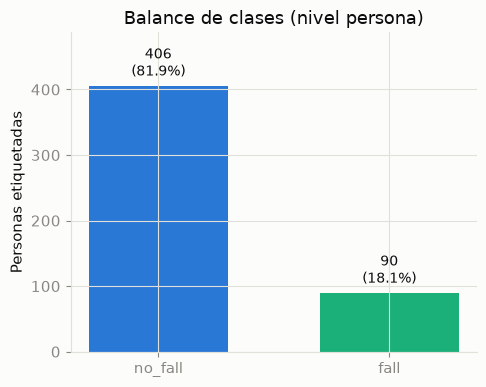

In [29]:
label_counts = bbox_log["label"].value_counts().reindex(["no_fall", "fall"])

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(label_counts.index, label_counts.values, color=[BLUE, AQUA], width=0.6)
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + max(label_counts) * 0.02,
            f"{val}\n({val / n_people:.1%})", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Personas etiquetadas")
ax.set_title("Balance de clases (nivel persona)")
ax.set_ylim(0, max(label_counts) * 1.2)
plt.tight_layout()
plt.show()


El desbalance (mas `no_fall` que `fall`) es esperable: en cualquier video o
banco de fotos, la mayoria de los frames muestran a alguien parado/caminando,
no cayendose. `train.py` compensa esto con **class weights** inversamente
proporcionales a la frecuencia de cada clase.


### 3.2 Distribucion por fuente (Pexels vs Video)

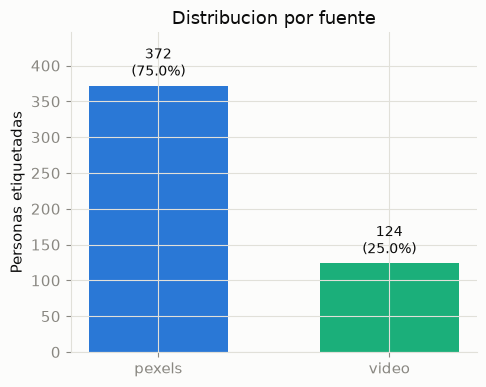

In [30]:
source_counts = bbox_log["source"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(source_counts.index, source_counts.values, color=[BLUE, AQUA], width=0.6)
for bar, val in zip(bars, source_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + max(source_counts) * 0.02,
            f"{val}\n({val / n_people:.1%})", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Personas etiquetadas")
ax.set_title("Distribucion por fuente")
ax.set_ylim(0, max(source_counts) * 1.2)
plt.tight_layout()
plt.show()


### 3.3 El cruce que importa: label × fuente

Si `fall` viniera casi todo de una sola fuente (por ejemplo, casi todo de
video) y `no_fall` casi todo de la otra (Pexels), el modelo podria aprender a
reconocer "pinta de frame de video" en vez de la caida real — un atajo que
infla las metricas offline pero no generaliza. Por eso `convert_dataset.py`
estratifica los splits por `(label, source)` en vez de solo por `label`.


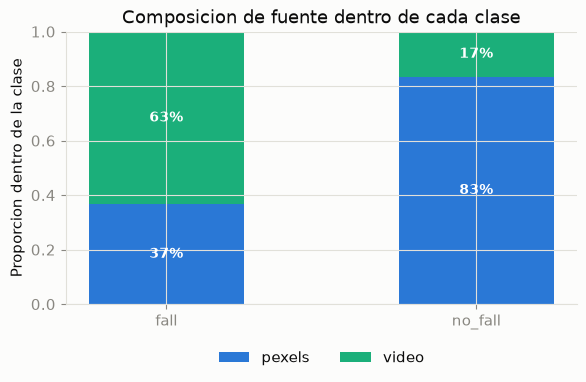

source   pexels  video
label                 
fall         33     57
no_fall     339     67

source  pexels  video
label                
fall     36.7%  63.3%
no_fall  83.5%  16.5%


In [31]:
cross = pd.crosstab(bbox_log["label"], bbox_log["source"])
cross_pct = cross.div(cross.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(6, 4))
labels = cross.index.tolist()
sources = cross.columns.tolist()
colors = [BLUE, AQUA, YELLOW, RED][: len(sources)]

bottom = np.zeros(len(labels))
for source, color in zip(sources, colors):
    values = cross_pct[source].values
    bars = ax.bar(labels, values, bottom=bottom, color=color, width=0.5, label=source)
    for i, (v, b) in enumerate(zip(values, bottom)):
        if v > 0.04:
            ax.text(i, b + v / 2, f"{v:.0%}", ha="center", va="center",
                     color="white", fontsize=10, fontweight="bold")
    bottom += values

ax.set_ylabel("Proporcion dentro de la clase")
ax.set_title("Composicion de fuente dentro de cada clase")
ax.set_ylim(0, 1)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=len(sources), frameon=False)
plt.tight_layout()
plt.show()

print(cross)
print()
print((cross_pct * 100).round(1).astype(str) + "%")


### 3.4 Verificacion: la estratificacion se mantuvo en los splits

In [32]:
split_cross = dataset_labels.groupby(["source", "label", "split"]).size().unstack(fill_value=0)
split_cross = split_cross.reindex(columns=["train", "valid", "test"])
split_pct = split_cross.div(split_cross.sum(axis=1), axis=0)

display_df = split_cross.astype(str) + "  (" + (split_pct * 100).round(0).astype(int).astype(str) + "%)"
display_df


split                train      valid       test
source label                                    
pexels fall      21  (64%)   5  (15%)   7  (21%)
       no_fall  232  (68%)  57  (17%)  50  (15%)
video  fall      32  (56%)   7  (12%)  18  (32%)
       no_fall   40  (60%)    6  (9%)  21  (31%)

Si la estratificacion funciono, la proporcion train/valid/test (~70/15/15)
deberia ser parecida en **todas** las filas (cada combinacion source x label),
no solo en el total.


### 3.5 Chequeo de fuga entre splits (imagenes con mas de una persona)

Como cada persona se estratifica por su propio `(label, source)`, una imagen
con dos personas de **distinta clase** podria terminar con un recorte en
`train` y otro en `test` — mismo fondo/escena en ambos splits, aunque sean
personas distintas. No es tan grave como una imagen duplicada exacta, pero
vale la pena saber cuanto pasa.


In [33]:
split_per_source = dataset_labels.groupby("source_image")["split"].nunique()
leaking = split_per_source[split_per_source > 1]

print(f"Imagenes originales con recortes en mas de un split: {len(leaking)} de {split_per_source.shape[0]}")
if len(leaking):
    print(
        dataset_labels[dataset_labels["source_image"].isin(leaking.index)]
        .sort_values("source_image")[["source_image", "filename", "label", "split"]]
        .to_string(index=False)
    )


Imagenes originales con recortes en mas de un split: 0 de 341


### 3.6 Densidad de anotaciones: personas por imagen y tamaño relativo del box

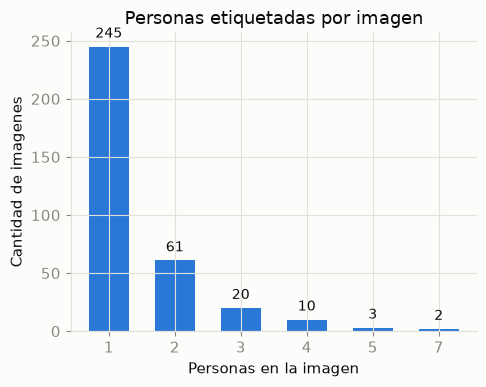

Imagenes con mas de una persona: 96 (28.2%)


In [34]:
people_per_image = bbox_log.groupby("filename").size()

fig, ax = plt.subplots(figsize=(5, 4))
counts = people_per_image.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color=BLUE, width=0.6)
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts) * 0.02, str(v), ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Personas en la imagen")
ax.set_ylabel("Cantidad de imagenes")
ax.set_title("Personas etiquetadas por imagen")
plt.tight_layout()
plt.show()

print(f"Imagenes con mas de una persona: {(people_per_image > 1).sum()} "
      f"({(people_per_image > 1).mean():.1%})")


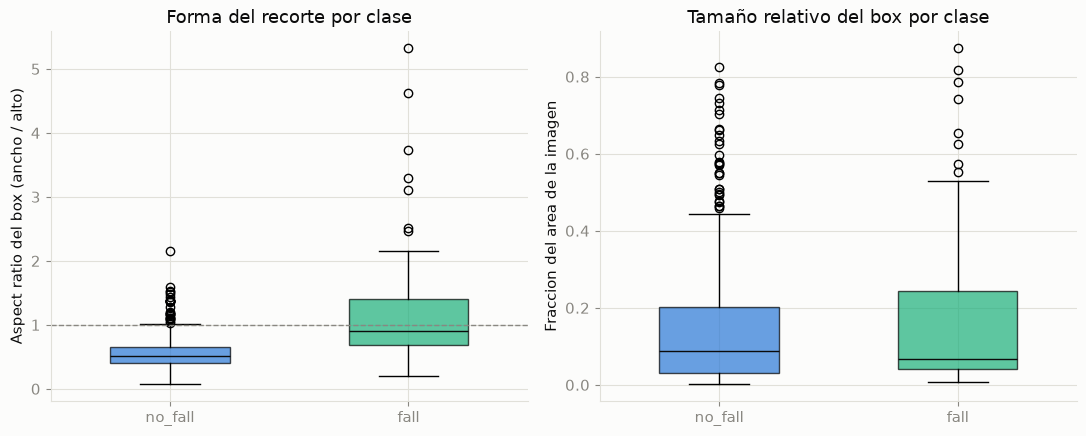

        aspect_ratio           area_fraction          
                mean       50%          mean       50%
label                                                 
fall        1.170294  0.901134      0.175742  0.067930
no_fall     0.561633  0.510972      0.147831  0.087812


In [35]:
bbox_log["box_width"] = bbox_log["x2"] - bbox_log["x1"]
bbox_log["box_height"] = bbox_log["y2"] - bbox_log["y1"]
bbox_log["aspect_ratio"] = bbox_log["box_width"] / bbox_log["box_height"]
# Normalizados 0-1: el producto es directamente la fraccion de area que ocupa
# la persona respecto a la escena completa.
bbox_log["area_fraction"] = bbox_log["box_width"] * bbox_log["box_height"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

data_ar = [bbox_log.loc[bbox_log["label"] == lbl, "aspect_ratio"] for lbl in ["no_fall", "fall"]]
bp = axes[0].boxplot(data_ar, tick_labels=["no_fall", "fall"], patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], [BLUE, AQUA]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp["medians"]:
    median.set_color(INK)
axes[0].axhline(1.0, color=MUTED, linestyle="--", linewidth=1)
axes[0].set_ylabel("Aspect ratio del box (ancho / alto)")
axes[0].set_title("Forma del recorte por clase")

data_area = [bbox_log.loc[bbox_log["label"] == lbl, "area_fraction"] for lbl in ["no_fall", "fall"]]
bp2 = axes[1].boxplot(data_area, tick_labels=["no_fall", "fall"], patch_artist=True, widths=0.5)
for patch, color in zip(bp2["boxes"], [BLUE, AQUA]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp2["medians"]:
    median.set_color(INK)
axes[1].set_ylabel("Fraccion del area de la imagen")
axes[1].set_title("Tamaño relativo del box por clase")

plt.tight_layout()
plt.show()

print(bbox_log.groupby("label")[["aspect_ratio", "area_fraction"]].describe().loc[:, (slice(None), ["mean", "50%"])])


Una persona caida suele generar un bounding box mas **ancho que alto** (el
cuerpo horizontal en el piso), mientras que una persona parada/caminando da
un box mas alto que ancho. Si esta diferencia es consistente, es una señal
util que el modelo deberia poder aprovechar — y una forma barata de detectar
etiquetados sospechosos (un "fall" con box muy vertical vale la pena revisar).


### 3.7 Ejemplos de recortes del dataset final

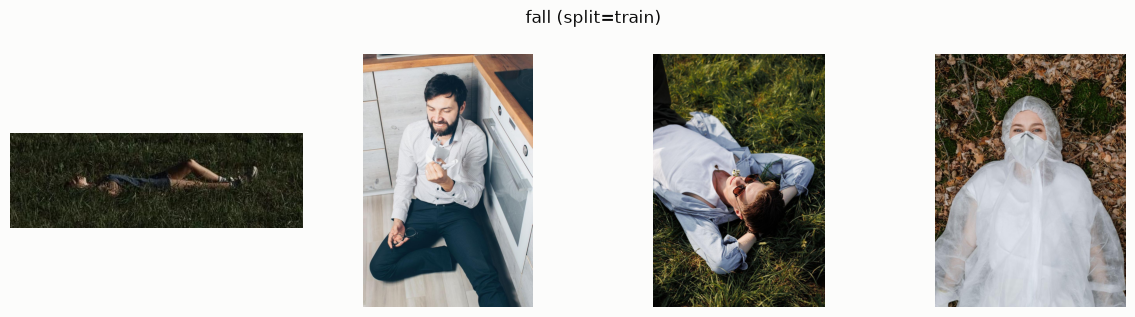

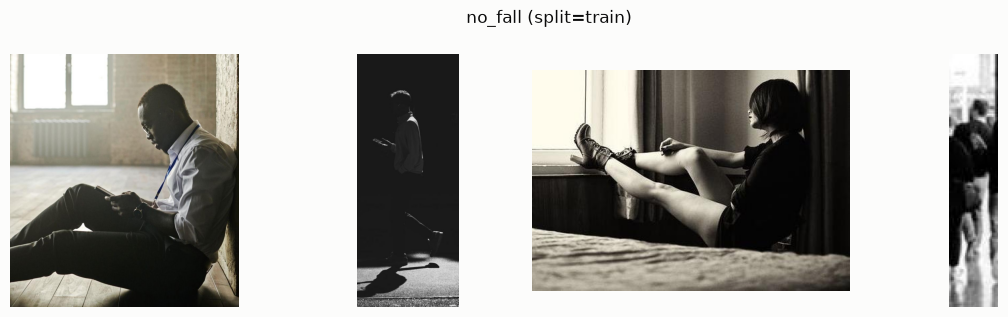

In [36]:
def sample_grid(label, n=4, split="train"):
    folder = PROCESSED_DIR / split / label
    files = sorted(folder.glob("*.jpg"))[:n]
    fig, axes = plt.subplots(1, len(files), figsize=(3 * len(files), 3.2))
    if len(files) == 1:
        axes = [axes]
    for ax, f in zip(axes, files):
        ax.imshow(Image.open(f))
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.suptitle(f"{label} (split={split})", fontsize=12)
    plt.tight_layout()
    plt.show()

sample_grid("fall")
sample_grid("no_fall")


## 4. Reduccion de dimensionalidad y duplicados

### 4.1 Casi-duplicados (dHash)

`scrape_dataset.py` ya descarta duplicados **exactos** por hash MD5 al
scrapear. Acá se busca algo mas laxo: imagenes **visualmente casi
identicas** (recortes ligeros, recompresion) con un perceptual hash (dHash)
casero — sin agregar `imagehash` como dependencia nueva, ya que es un
algoritmo de pocas lineas sobre PIL puro.


In [37]:
def dhash(image, hash_size=8):
    small = image.convert("L").resize((hash_size + 1, hash_size), Image.LANCZOS)
    pixels = np.asarray(small, dtype=np.int16)
    return (pixels[:, 1:] > pixels[:, :-1]).flatten()

hashes = {}
for f in raw_files:
    try:
        with Image.open(f) as img:
            hashes[f.name] = dhash(img)
    except Exception:
        continue

names = list(hashes.keys())
DUPLICATE_THRESHOLD = 4  # distancia de Hamming sobre 64 bits: <=4 = muy similares
near_duplicates = []
for i in range(len(names)):
    hi = hashes[names[i]]
    for j in range(i + 1, len(names)):
        dist = np.count_nonzero(hi != hashes[names[j]])
        if dist <= DUPLICATE_THRESHOLD:
            near_duplicates.append((names[i], names[j], dist))

print(f"Pares casi-duplicados encontrados (Hamming <= {DUPLICATE_THRESHOLD} / 64 bits): {len(near_duplicates)}")
for a, b, d in near_duplicates[:10]:
    print(f"  {a}  <->  {b}   (distancia {d})")


Pares casi-duplicados encontrados (Hamming <= 4 / 64 bits): 136
  vid_fall_compilation_2024_000000.jpg  <->  vid_fall_compilation_2024_000120.jpg   (distancia 2)
  vid_fall_compilation_2024_000000.jpg  <->  vid_fall_compilation_2024_000180.jpg   (distancia 2)
  vid_fall_compilation_2024_000120.jpg  <->  vid_fall_compilation_2024_000180.jpg   (distancia 0)
  vid_fall_compilation_2024_000120.jpg  <->  vid_fall_compilation_2024_002400.jpg   (distancia 4)
  vid_fall_compilation_2024_000180.jpg  <->  vid_fall_compilation_2024_002400.jpg   (distancia 4)
  vid_fall_compilation_2024_000300.jpg  <->  vid_fall_compilation_2024_003540.jpg   (distancia 4)
  vid_fall_compilation_2024_000720.jpg  <->  vid_fall_compilation_2024_002340.jpg   (distancia 2)
  vid_fall_compilation_2024_000960.jpg  <->  vid_fall_compilation_2024_001020.jpg   (distancia 3)
  vid_fall_compilation_2024_000960.jpg  <->  vid_fall_compilation_2024_001740.jpg   (distancia 4)
  vid_fall_compilation_2024_000960.jpg  <->  vid_fall_

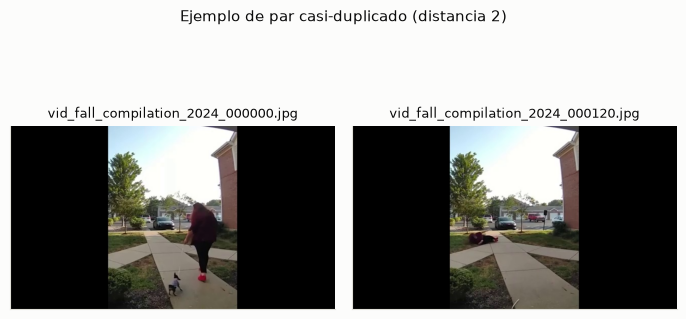

In [38]:
if near_duplicates:
    a_name, b_name, dist = near_duplicates[0]
    fig, axes = plt.subplots(1, 2, figsize=(7, 4))
    axes[0].imshow(Image.open(LABELED_DIR / a_name)); axes[0].set_title(a_name, fontsize=9)
    axes[1].imshow(Image.open(LABELED_DIR / b_name)); axes[1].set_title(b_name, fontsize=9)
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"Ejemplo de par casi-duplicado (distancia {dist})", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron casi-duplicados con el umbral actual.")


**Chequeo critico**: de los pares casi-duplicados de arriba, ¿cuantos tienen
sus recortes en splits **completamente distintos**? Si un frame de train es
casi identico a uno de test, el modelo no esta siendo evaluado de forma
honesta en esos casos — es la version mas seria de fuga de datos que puede
tener este dataset.


In [39]:
split_of_image = dataset_labels.groupby("source_image")["split"].apply(set).to_dict()

cross_split_dupes = [
    (a, b, split_of_image.get(a), split_of_image.get(b))
    for a, b, _ in near_duplicates
    if split_of_image.get(a) and split_of_image.get(b)
    and not (split_of_image[a] & split_of_image[b])
]

print(f"Pares casi-duplicados con splits totalmente distintos: {len(cross_split_dupes)} de {len(near_duplicates)}")
for a, b, sa, sb in cross_split_dupes[:15]:
    print(f"  {a} ({sa})  <->  {b} ({sb})")


Pares casi-duplicados con splits totalmente distintos: 0 de 136


### 4.2 Proyeccion t-SNE de embeddings del modelo entrenado

En vez de usar un extractor generico de ImageNet, se usan los embeddings de
la **penultima capa** del propio `models/resnet18.pth` ya entrenado (512-d,
antes de la capa `fc` de clasificacion) — muestra como el modelo entrenado
organiza internamente el dataset, no solo como se ve a simple vista.


In [40]:
import torch
from src.core.model import get_model
from src.core.preprocessing.transforms import get_test_transforms

model_path = ROOT / "models" / "resnet18.pth"

if not model_path.exists():
    print("Todavia no hay un modelo entrenado en models/resnet18.pth — corre python -m src.core.train primero.")
else:
    model = get_model(pretrained=False)
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()
    feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
    transform = get_test_transforms()

    embeddings, emb_labels = [], []
    with torch.no_grad():
        for split in ["train", "valid", "test"]:
            for label in ["fall", "no_fall"]:
                folder = PROCESSED_DIR / split / label
                for f in sorted(folder.glob("*.jpg")):
                    img = Image.open(f).convert("RGB")
                    tensor = transform(img).unsqueeze(0)
                    feat = feature_extractor(tensor).flatten().numpy()
                    embeddings.append(feat)
                    emb_labels.append(label)

    embeddings = np.array(embeddings)
    emb_labels = np.array(emb_labels)
    print(f"Embeddings extraidos: {embeddings.shape}")


ModuleNotFoundError: No module named 'torch'

In [ ]:
if model_path.exists():
    from sklearn.manifold import TSNE

    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca")
    proj = tsne.fit_transform(embeddings)

    fig, ax = plt.subplots(figsize=(6, 6))
    colors = {"no_fall": BLUE, "fall": AQUA}
    for label in ["no_fall", "fall"]:
        mask = emb_labels == label
        ax.scatter(proj[mask, 0], proj[mask, 1], c=colors[label], label=label,
                   alpha=0.7, s=25, edgecolors="none")
    ax.legend(frameon=False)
    ax.set_title("t-SNE de embeddings del modelo entrenado (penultima capa)")
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()


Si las dos clases forman regiones separadas (aunque sea parcialmente), el
modelo aprendio una representacion que distingue `fall` de `no_fall` mas alla
de memorizar ejemplos puntuales. Si estan completamente mezcladas, es señal de
que falta señal discriminativa (mas datos, mejor recorte, o mas epochs).


## Resumen

- **Archivos**: se auditaron todas las imagenes crudas en `data/raw/labeled/`
  (formato, integridad, resolucion, aspect ratio) antes de mirar contenido o
  clases. Sin corruptos ni 0 KB.
- **Pixeles**: brillo, contraste, nitidez y balance de color no muestran
  problemas sistematicos evidentes (ver seccion 2 para las imagenes menos
  nitidas puntuales).
- **Clases**: el desbalance `fall`/`no_fall` esta parcialmente confundido con
  la fuente (`pexels`/`video`), pero la estratificacion en
  `convert_dataset.py` evita que esto se traduzca en splits sesgados por
  fuente. La forma del bounding box (mas ancho que alto en `fall`) es una
  señal adicional coherente con la fisica del problema.
- ⚠️ **Fuga de datos entre splits (el hallazgo mas importante de este EDA)**:
  cerca de la mitad de los pares casi-duplicados detectados por dHash
  (frames de video muy cercanos entre si) tienen sus recortes repartidos
  entre splits **distintos** — el mismo momento del video, practicamente la
  misma imagen, aparece a la vez en train y en test. Esto probablemente esta
  inflando la accuracy de test reportada por `evaluate.py`. La causa raiz es
  que `convert_dataset.py` estratifica por `(label, source)` a nivel
  **persona**, sin agrupar por video/clip de origen. Antes de confiar en las
  metricas actuales, valdria la pena que el split agrupe por clip de video
  (todas las personas de un mismo clip van al mismo split), no solo por
  persona individual.
- **Embeddings**: la proyeccion t-SNE del modelo ya entrenado da una primera
  idea de que tan separables son las clases en el espacio aprendido.
